
# NBA Shot Data — Holistic Exploration
This notebook helps you build a holistic understanding of NBA shot data using common visuals:
- Overview metrics
- Shot selection (2 vs 3), distance distribution
- Court shot chart (sampled)
- Player FG% leaders (with volume filter)
- FG% heatmap by (distance × shot clock)
- Team-level shot profiles (3PA rate vs FG%, bubble = avg distance)

**Notes**
- Uses only `matplotlib` for plotting (no seaborn), each chart in a single figure (no subplots).
- Works with the uploaded CSV schema (2013 enriched shots). You can point to other seasons later.
- If columns are missing in other seasons, cells will gracefully skip those visuals.


In [9]:

# === 0. Setup & Load ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your uploaded file (adjust if needed)
FILE_PATH = "enriched_data/nba_savant_2013_enriched_shots_v2.csv"

shots = pd.read_csv(FILE_PATH)
print(f"Loaded {len(shots):,} shots with {shots.shape[1]} columns.")
shots.head(3)


Loaded 204,126 shots with 29 columns.


,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,defender_name,defender_distance,shot_clock,team,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons,shotValue
0,James Johnson,Memphis Grizzlies,2014-03-12,2013,3999.0,1610612763,400489836,4,11,30,...,"Miller, Darius",2.4,12.5,MEM,12.5,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
1,Jerryd Bayless,Memphis Grizzlies,2013-12-23,2013,3417.0,1610612763,400489286,2,8,27,...,"Burks, Alec",3.7,24.0,MEM,24.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
2,Tony Allen,Memphis Grizzlies,2014-03-19,2013,2367.0,1610612763,400489884,3,3,58,...,"Kanter, Enes",4.5,8.6,MEM,8.6,from_savant_shot_clock,1,borderline,location: at-rim/very close,2


In [10]:

# === 1. Quick Schema & Basic Hygiene ===
print(shots.dtypes)
missing_by_col = shots.isna().mean().sort_values(ascending=False)
print("\nMissing ratio by column (top 10):")
print(missing_by_col.head(10))

# Standardize a few expected columns if present
rename_map = {
    'team': 'team_name',
    'shot_distance': 'shot_distance',
    'shot_made_flag': 'shot_made_flag',
    'x': 'x', 'y': 'y',
    'shotValue': 'shotValue',
    'shot_clock': 'shot_clock',
}
# (no actual renames, just a place-holder pattern if needed later)
shots = shots.copy()
shots


name                  object
team_name             object
game_date             object
season                 int64
espn_player_id       float64
team_id                int64
espn_game_id           int64
period                 int64
minutes_remaining      int64
seconds_remaining      int64
shot_made_flag         int64
action_type           object
shot_type             object
shot_distance          int64
opponent              object
x                      int64
y                      int64
dribbles               int64
touch_time           float64
defender_name         object
defender_distance    float64
shot_clock           float64
team                  object
SHOT_CLOCK_APPROX    float64
SHOT_CLOCK_SOURCE     object
contest_score          int64
contest_label         object
contest_reasons       object
shotValue              int64
dtype: object

Missing ratio by column (top 10):
espn_player_id       0.009328
defender_name        0.007270
contest_reasons      0.001798
name                

,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,defender_name,defender_distance,shot_clock,team,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons,shotValue
0,James Johnson,Memphis Grizzlies,2014-03-12,2013,3999.0,1610612763,400489836,4,11,30,...,"Miller, Darius",2.4,12.5,MEM,12.5,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
1,Jerryd Bayless,Memphis Grizzlies,2013-12-23,2013,3417.0,1610612763,400489286,2,8,27,...,"Burks, Alec",3.7,24.0,MEM,24.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
2,Tony Allen,Memphis Grizzlies,2014-03-19,2013,2367.0,1610612763,400489884,3,3,58,...,"Kanter, Enes",4.5,8.6,MEM,8.6,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
3,Kosta Koufos,Memphis Grizzlies,2014-03-19,2013,3444.0,1610612763,400489884,4,10,54,...,"Williams, Marvin",8.3,14.1,MEM,14.1,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
4,Ed Davis,Memphis Grizzlies,2013-11-06,2013,4259.0,1610612763,400488938,4,8,48,...,"Stiemsma, Greg",7.8,19.6,MEM,19.6,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204121,Joakim Noah,Chicago Bulls,2013-11-18,2013,3224.0,1610612741,400489024,1,10,18,...,"Biyombo, Bismack",2.0,0.0,CHI,0.0,from_savant_shot_clock,3,likely_contested,"action: contested-like, action: open-like, loc...",2
204122,Taj Gibson,Chicago Bulls,2014-01-22,2013,3986.0,1610612741,400489495,3,10,1,...,"Varejao, Anderson",2.3,8.2,CHI,8.2,from_savant_shot_clock,2,likely_contested,"action: contested-like, action: open-like, loc...",2
204123,Joakim Noah,Chicago Bulls,2013-12-19,2013,3224.0,1610612741,400489254,3,5,27,...,"Ibaka, Serge",1.6,7.7,CHI,7.7,from_savant_shot_clock,2,likely_contested,"action: contested-like, action: open-like, loc...",2
204124,Taj Gibson,Chicago Bulls,2013-12-07,2013,3986.0,1610612741,400489165,1,11,17,...,"Smith, Josh",3.3,0.0,CHI,0.0,from_savant_shot_clock,3,likely_contested,"action: contested-like, action: open-like, loc...",2


## 2. Overview KPIs

In [11]:

total_shots = len(shots)
fg_pct = shots['shot_made_flag'].mean() if 'shot_made_flag' in shots else np.nan
seasons = shots['season'].dropna().unique() if 'season' in shots else []

print(f"Total shots: {total_shots:,}")
print(f"Overall FG%: {fg_pct:.2%}" if not np.isnan(fg_pct) else "Overall FG%: N/A")
print(f"Seasons present: {sorted(seasons)}")


Total shots: 204,126
Overall FG%: 45.45%
Seasons present: [np.int64(2013)]


## 3. Shot Selection — 2PA vs 3PA

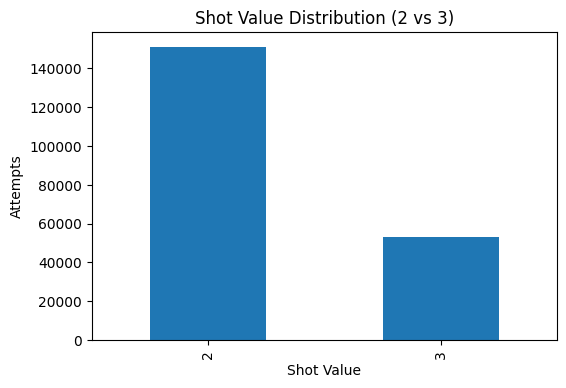

In [12]:

if 'shotValue' in shots:
    vc = shots['shotValue'].value_counts().sort_index()
    fig = plt.figure(figsize=(6,4))
    vc.plot(kind='bar')
    plt.title("Shot Value Distribution (2 vs 3)")
    plt.xlabel("Shot Value")
    plt.ylabel("Attempts")
    plt.show()
else:
    print("Column 'shotValue' not found; skipping this chart.")


## 4. Shot Distance Distribution

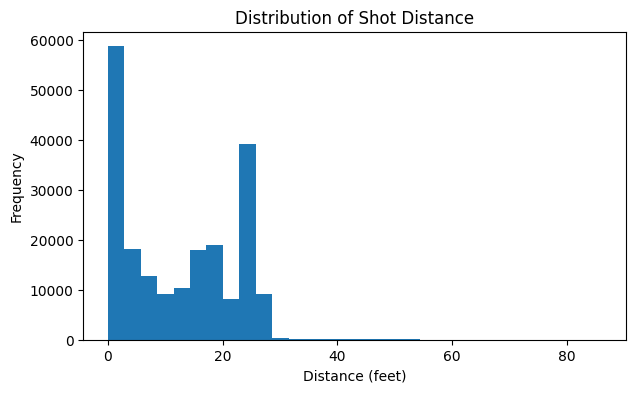

In [13]:

col = 'shot_distance' if 'shot_distance' in shots else ('shotDistance' if 'shotDistance' in shots else None)
if col is not None:
    fig = plt.figure(figsize=(7,4))
    plt.hist(shots[col].dropna(), bins=30)
    plt.title("Distribution of Shot Distance")
    plt.xlabel("Distance (feet)")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No distance column found (expected 'shot_distance' or 'shotDistance').")


## 5. Court Shot Chart (Sampled)

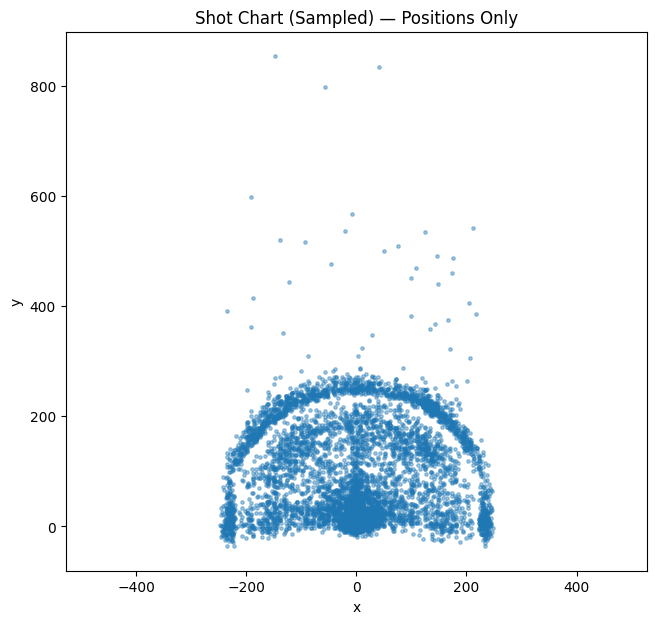

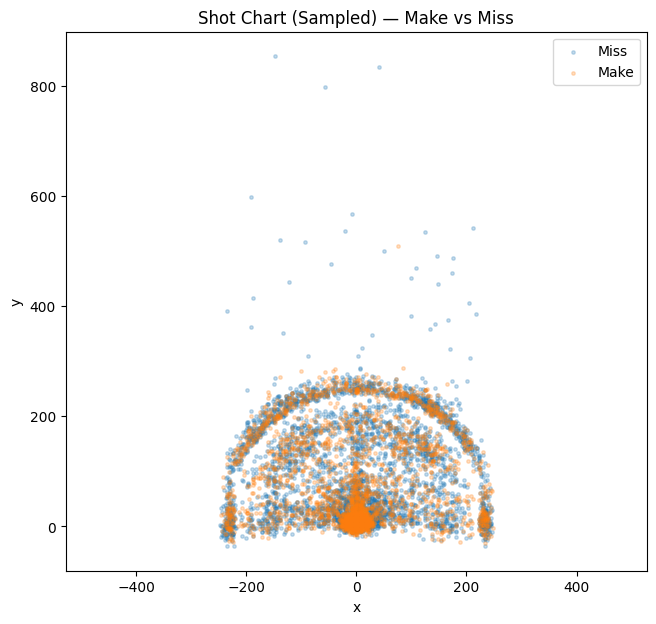

In [14]:

# For performance, sample a subset
need_cols = {'x','y','shot_made_flag'}
if need_cols.issubset(shots.columns):
    sample_n = min(7500, len(shots))
    sampled = shots.sample(sample_n, random_state=42)[['x','y','shot_made_flag']].dropna()

    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(sampled['x'], sampled['y'], s=6, alpha=0.4, label=None)
    plt.title("Shot Chart (Sampled) — Positions Only")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.show()

    # Optional: overlay make vs miss (two passes to avoid explicit colors)
    made = sampled[sampled['shot_made_flag'] == 1]
    miss = sampled[sampled['shot_made_flag'] == 0]
    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(miss['x'], miss['y'], s=6, alpha=0.25, label="Miss")
    plt.scatter(made['x'], made['y'], s=6, alpha=0.25, label="Make")
    plt.title("Shot Chart (Sampled) — Make vs Miss")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.legend()
    plt.show()
else:
    print("Columns x, y, shot_made_flag not found; skipping shot chart.")


## 6. Player FG% Leaders (min attempts filter)

Players with at least 200 attempts: 298


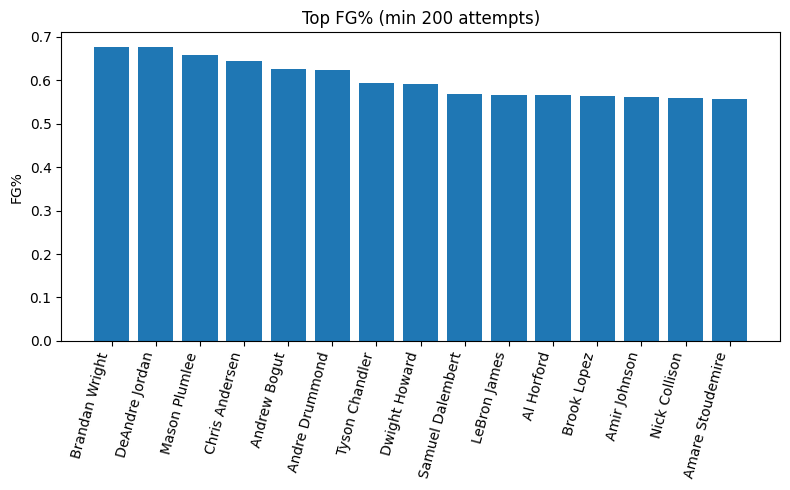

In [15]:

req = {'name','shot_made_flag'}
if req.issubset(shots.columns):
    player_stats = (
        shots.groupby('name', dropna=False)
             .agg(attempts=('shot_made_flag','size'),
                  fg_pct=('shot_made_flag','mean'))
             .reset_index()
    )
    min_att = 200
    leaders = player_stats.query('attempts >= @min_att').sort_values('fg_pct', ascending=False).head(15)
    print(f"Players with at least {min_att} attempts: {len(player_stats.query('attempts >= @min_att'))}")
    fig = plt.figure(figsize=(8,5))
    # bar plot via matplotlib for consistent styling
    plt.bar(leaders['name'], leaders['fg_pct'])
    plt.title("Top FG% (min 200 attempts)")
    plt.ylabel("FG%")
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Columns 'name' and/or 'shot_made_flag' missing; skipping player leaders.")


## 7. FG% Heatmap — Distance × Shot Clock

/var/folders/02/8qskm_yj6gx6xyj73fgxk36h0000gp/T/ipykernel_11048/3249250913.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = shots.pivot_table(values='shot_made_flag', index=dist_cuts, columns=clock_cuts, aggfunc='mean')


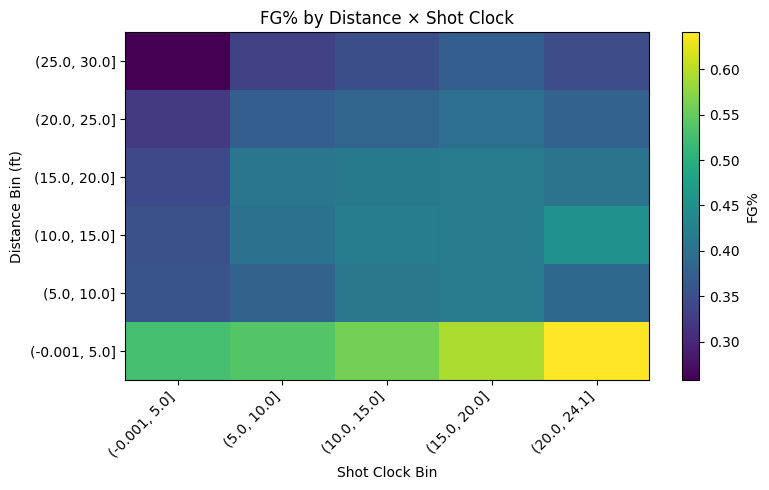

In [16]:

if {'shot_made_flag','shot_distance','shot_clock'}.issubset(shots.columns):
    # Bin distance and shot clock
    dist_bins = [0,5,10,15,20,25,30]
    clock_bins = [0,5,10,15,20,24.1]  # include 24
    dist_cuts = pd.cut(shots['shot_distance'], bins=dist_bins, include_lowest=True)
    clock_cuts = pd.cut(shots['shot_clock'], bins=clock_bins, include_lowest=True)
    pivot = shots.pivot_table(values='shot_made_flag', index=dist_cuts, columns=clock_cuts, aggfunc='mean')

    fig = plt.figure(figsize=(8,5))
    plt.imshow(pivot.values, aspect='auto', origin='lower')
    plt.title("FG% by Distance × Shot Clock")
    plt.xlabel("Shot Clock Bin")
    plt.ylabel("Distance Bin (ft)")
    plt.colorbar(label="FG%")
    # Put readable ticks
    plt.xticks(ticks=np.arange(len(pivot.columns)), labels=[str(c) for c in pivot.columns], rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(pivot.index)), labels=[str(i) for i in pivot.index])
    plt.tight_layout()
    plt.show()
else:
    print("Need 'shot_made_flag', 'shot_distance', and 'shot_clock'; skipping heatmap.")


## 8. Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)

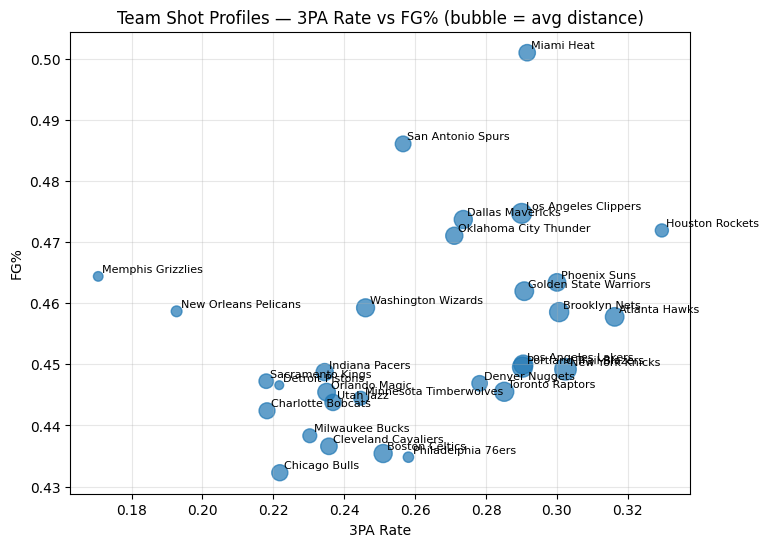

In [19]:

cols = {'team_name','shotValue','shot_made_flag','shot_distance'}
if cols.issubset(shots.columns):
    team_shots = (shots.groupby('team_name')
                         .agg(avg_dist=('shot_distance','mean'),
                              three_rate=('shotValue', lambda x: np.mean(x==3)),
                              fg_pct=('shot_made_flag','mean'))
                         .reset_index())

    fig = plt.figure(figsize=(8,6))
    sizes = 200 * (team_shots['avg_dist'] - team_shots['avg_dist'].min()) / (team_shots['avg_dist'].max() - team_shots['avg_dist'].min() + 1e-9) + 40
    plt.scatter(team_shots['three_rate'], team_shots['fg_pct'], s=sizes, alpha=0.7)
    for _, r in team_shots.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['fg_pct']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)")
    plt.xlabel("3PA Rate")
    plt.ylabel("FG%")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Missing one of ['team_name','shotValue','shot_made_flag','shot_distance']; skipping team profiles.")


## 9. Optional: Hexbin Efficiency (league-wide)

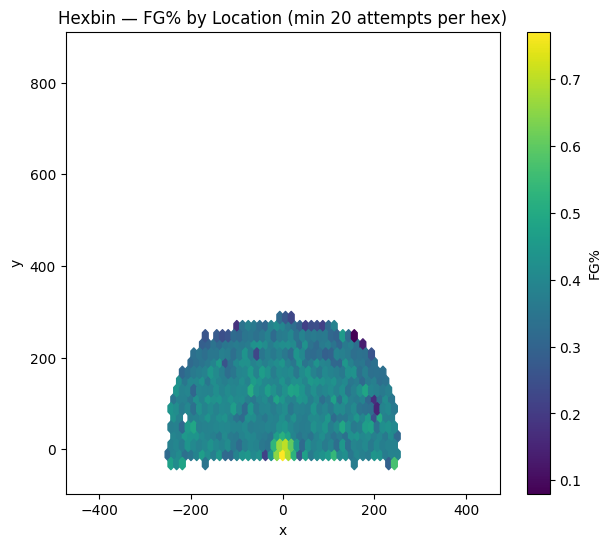

In [18]:

# Simple location hexbin colored by FG%
need = {'x','y','shot_made_flag'}
if need.issubset(shots.columns):
    # Compute FG% per hex using matplotlib's hexbin counts with weights
    x = shots['x'].values
    y = shots['y'].values
    w = shots['shot_made_flag'].values.astype(float)
    fig = plt.figure(figsize=(7,6))
    hb = plt.hexbin(x, y, C=w, gridsize=40, reduce_C_function=np.mean, mincnt=20)  # mincnt to reduce noise
    plt.title("Hexbin — FG% by Location (min 20 attempts per hex)")
    plt.xlabel("x")
    plt.ylabel("y")
    cb = plt.colorbar(hb)
    cb.set_label("FG%")
    plt.axis('equal')
    plt.show()
else:
    print("Columns x, y, shot_made_flag not found; skipping hexbin.")



## 10. Comparing Seasons (How-To)
If you have multiple seasons:
1. Load each season's CSV into a separate DataFrame and add a `season` column if missing.
2. Concatenate into one `shots_all` DataFrame.
3. Re-run the visuals grouped by `season` (e.g., filter `shots_all[shots_all['season']==2016]`).

> Tip: For A/B comparisons, compute per-team/per-player metrics per season, and then plot deltas (season B − season A).
